## import library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

## Loading dataset

In [2]:
df=pd.read_csv('dataset.csv')

## checking for missing value

In [ ]:
df.isna().sum()
# df.drop_duplicates(subset=['email'],inplace=True,keep='first')  remove duplicate rows and keep thr first one remove every row 
# df.pivot
    # df=df.pivot(index='month',columns='city',values='temperature')
    # index is the column which you hace to use as row ,columns is the columns you have to use as new columns and values is value to have to fill inside


[7043, 21]

## checking datatype for each column

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


#### monthly charges and total charges need to get convert into integer

In [ ]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce',downcast='int')
d

### Handiling missing value now

In [79]:
df.isna().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [80]:
df['TotalCharges'].fillna(df['TotalCharges'].median() ,inplace=True)

/tmp/ipykernel_16921/2842175201.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median() ,inplace=True)


## Now we will check for churn and non churn customers 

In [81]:
print(df['Churn'].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


/tmp/ipykernel_16921/3679690284.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.countplot(x='Churn',data=df,palette='coolwarm')


<Axes: xlabel='Churn', ylabel='count'>

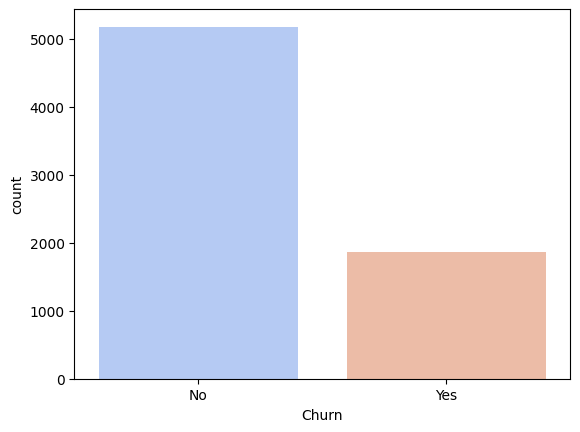

In [82]:
sb.countplot(x='Churn',data=df,palette='coolwarm')

### Now doing label Encoding

In [83]:
l=list(df.columns)

In [84]:
l

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [85]:
l.remove('customerID')
l.remove('TotalCharges')
l.remove('tenure')
l.remove('MonthlyCharges')
l.remove('SeniorCitizen')

In [86]:
l

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

In [87]:
from sklearn.preprocessing import LabelEncoder
lb=LabelEncoder()
for i in l:
    df[i]=lb.fit_transform(df[i])

In [88]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,1,2,29.85,29.85,0
1,5575-GNVDE,1,0,0,0,34,1,0,0,2,...,2,0,0,0,1,0,3,56.95,1889.50,0
2,3668-QPYBK,1,0,0,0,2,1,0,0,2,...,0,0,0,0,0,1,3,53.85,108.15,1
3,7795-CFOCW,1,0,0,0,45,0,1,0,2,...,2,2,0,0,1,0,0,42.30,1840.75,0
4,9237-HQITU,0,0,0,0,2,1,0,1,0,...,0,0,0,0,0,1,2,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,1,0,1,1,24,1,2,0,2,...,2,2,2,2,1,1,3,84.80,1990.50,0
7039,2234-XADUH,0,0,1,1,72,1,2,1,0,...,2,0,2,2,1,1,1,103.20,7362.90,0
7040,4801-JZAZL,0,0,1,1,11,0,1,0,2,...,0,0,0,0,0,1,2,29.60,346.45,0
7041,8361-LTMKD,1,1,1,0,4,1,2,1,0,...,0,0,0,0,0,1,3,74.40,306.60,1


### Spillting Data into X and y

In [89]:
X=df.drop(columns=['customerID','Churn'],axis=1)
y=df['Churn']

In [90]:
y

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7043, dtype: int64

In [91]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [92]:
X_train,X_test

(      gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
 2142       0              0        0           1      21             1   
 1623       0              0        0           0      54             1   
 6074       1              0        1           0       1             0   
 1362       1              0        0           0       4             1   
 6754       1              0        0           1       0             1   
 ...      ...            ...      ...         ...     ...           ...   
 3772       1              0        1           0       1             1   
 5191       0              0        1           1      23             1   
 5226       1              0        1           1      12             1   
 5390       1              1        0           0      12             1   
 860        1              0        0           0      26             1   
 
       MultipleLines  InternetService  OnlineSecurity  OnlineBackup  \
 2142              0       

In [93]:
y_train,y_test

(2142    0
 1623    0
 6074    1
 1362    1
 6754    0
        ..
 3772    1
 5191    0
 5226    0
 5390    1
 860     0
 Name: Churn, Length: 5634, dtype: int64,
 185     1
 2715    0
 3825    0
 1807    1
 132     0
        ..
 6366    0
 315     0
 2439    0
 5002    0
 1161    1
 Name: Churn, Length: 1409, dtype: int64)

## Feature Scaling

In [94]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

## Applying the RandomForestClassifier

In [95]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

In [96]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.8026969481902059

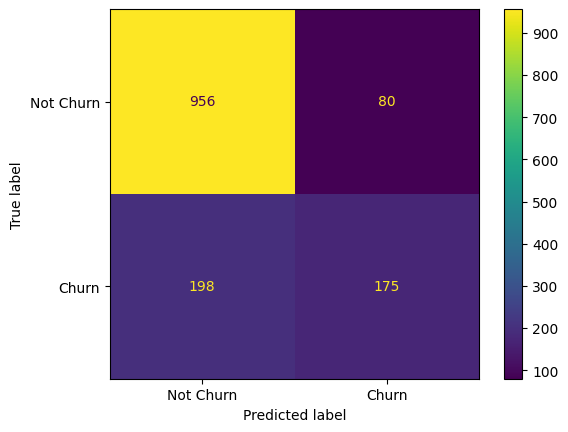

In [97]:
from sklearn.metrics import ConfusionMatrixDisplay,confusion_matrix
cm=ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test,y_pred),display_labels=["Not Churn","Churn"])
cm.plot()